In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading In

My dataset is a collection of weather reports recorded at Los Angeles International Airport in 2025. I thought the dataset might provide some interesting insights, though honestly at the start of this I had no idea what my data represented. Overall though, I was able to extract meaninigful insights and discovered interesting relationships. 

The first thing I did was read in the dataset, and began looking over it. I think the most time-intensive part of the whole project was understanding what my dataset was even trying to accomplish, and rationalizing what each column represented.

In [5]:
df = pd.read_csv("LCD_USW00023174_2025.csv", low_memory=False)
df

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,SOURCE,HourlyAltimeterSetting,HourlyDewPointTemperature,...,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,BackupEquipment,BackupLatitude,BackupLongitude,BackupName,WindEquipmentChangeDate
0,USW00023174,2025-01-01T00:00:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",SOD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
1,USW00023174,2025-01-01T00:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,343.0,1018.3,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
2,USW00023174,2025-01-01T01:00:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-12,223.0,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
3,USW00023174,2025-01-01T01:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,343.0,1018.6,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
4,USW00023174,2025-01-01T02:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,343.0,1018.6,9.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13957,USW00023174,2025-12-31T21:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,223.0,1016.6,12.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
13958,USW00023174,2025-12-31T22:00:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-12,223.0,NaN,12.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
13959,USW00023174,2025-12-31T22:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,223.0,1016.6,13.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006
13960,USW00023174,2025-12-31T23:53:00,33.938,-118.3888,29.6,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",FM-15,223.0,1016.3,13.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10/27/2006


One thing that initially concerned me was the amount of na values. I tried dropping na rows...and I ended up with an empty dataset.

In [8]:
print(df.copy().dropna(inplace=True))
print(df.describe())

None
           LATITUDE     LONGITUDE     ELEVATION        SOURCE  \
count  1.396200e+04  1.396200e+04  1.396200e+04  13585.000000   
mean   3.393800e+01 -1.183888e+02  2.960000e+01    283.967243   
std    7.105682e-15  4.263409e-14  3.552841e-15     59.994411   
min    3.393800e+01 -1.183888e+02  2.960000e+01    223.000000   
25%    3.393800e+01 -1.183888e+02  2.960000e+01    223.000000   
50%    3.393800e+01 -1.183888e+02  2.960000e+01    343.000000   
75%    3.393800e+01 -1.183888e+02  2.960000e+01    343.000000   
max    3.393800e+01 -1.183888e+02  2.960000e+01    343.000000   

       HourlyAltimeterSetting  HourlyDewPointTemperature  \
count            10743.000000               13585.000000   
mean              1015.640808                  12.171498   
std                  3.296199                   4.473448   
min               1005.100000                 -12.800000   
25%               1013.500000                  10.600000   
50%               1015.600000                  13

# Dataset Structure

However, one thing I noticed when looking closer was that I did have a lot of information. Tons of rows had tons of entries, it was just inconsistent. What I found was that the dataset as a whole was broken into subsections, based on what type of report it was. After doing some research, this made more sense.

The dataset was broken up into multiple types of reports; FM-15, FM-12, and FM-16 were hourly reports that contained very timely data, whereas SOD and SOM represented Summary of Day and Summary of Month reports respectively. The many NaNs I had were a result of there being columns specifically for hourly, daily, or monthly reports, so naturally no row would be devoid of missing values.

In [32]:
print(df['REPORT_TYPE'].value_counts())

print("Total length: ", len(df))
print("Length per report type: ", df['REPORT_TYPE'].value_counts().sum())
print("\n\nNumber of columns: ", len(df.columns))

REPORT_TYPE
FM-15    8646
FM-12    2841
FM-16    2098
SOD       365
SOM        12
Name: count, dtype: int64
Total length:  13962
Length per report type:  13962


Number of columns:  125


# Cleaning

Proceding from there, there were still a lot of columns with minimal value counts. So I dropped columns many that wouldn't have been very practical for analysis. 

In [33]:
drops = []
for col in df.columns:
    vals = df[col].value_counts()
    # print(vals)
    if len(vals) == 1 or len(vals) == 0:
        drops.append(col)

print("Should drop: ", drops)
df.drop(columns=drops, inplace=True)

Should drop:  ['STATION', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'DailyAverageDewPointTemperature', 'DailyAverageRelativeHumidity', 'DailyAverageSeaLevelPressure', 'DailyAverageStationPressure', 'DailyAverageWetBulbTemperature', 'DailySnowDepth', 'DailySnowfall', 'MonthlyAverageRH', 'MonthlyDaysWithGT32Temp', 'MonthlyDaysWithLT0Temp', 'MonthlyDaysWithLT32Temp', 'MonthlyDewpointTemperature', 'MonthlyGreatestSnowDepth', 'MonthlyGreatestSnowDepthDate', 'MonthlyGreatestSnowfall', 'MonthlyGreatestSnowfallDate', 'MonthlySeaLevelPressure', 'MonthlyStationPressure', 'MonthlyTotalSnowfall', 'MonthlyWetBulb', 'MonthlyNumberDaysWithSnowfall', 'MonthlyNumberDaysWithThunderstorms', 'BackupDirection', 'BackupDistance', 'BackupDistanceUnit', 'BackupElements', 'BackupElevation', 'BackupEquipment', 'BackupLatitude', 'BackupLongitude', 'BackupName', 'WindEquipmentChangeDate']


There were also several columns that I just couldn't make sense of, so I decided not to use them. After that, I split my data into sections of hourly, daily, and monthly information so I could examine each. Within these, I had very few null values, so my initial concerns were just a result of the datasets structure, not bad information.

In [34]:
df.drop(columns=['REM', 'SOURCE'], inplace=True)
df_hourly = df.copy()[(df['REPORT_TYPE'] == 'FM-15') | (df['REPORT_TYPE'] == 'FM-12') | (df['REPORT_TYPE'] == 'FM-16')]
for col in df_hourly.columns:
    # print("For", col, ":", df_hourly[col].count())
    if df_hourly[col].count() < 5000:
        df_hourly.drop(columns=[col], inplace=True)

df_daily = df.copy()[df['REPORT_TYPE'] == 'SOD']
for col in df_daily.columns:
    # print("For", col, ":", df_hourly[col].count())
    if df_daily[col].count() < 10:
        df_daily.drop(columns=[col], inplace=True)

        
df_monthly = df.copy()[df['REPORT_TYPE'] == 'SOM']
for col in df_monthly.columns:
    # print("For", col, ":", df_hourly[col].count())
    if df_monthly[col].count() < 10:
        df_monthly.drop(columns=[col], inplace=True)

df_hourly

,DATE,REPORT_TYPE,HourlyAltimeterSetting,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPressureChange,HourlyPressureTendency,HourlyRelativeHumidity,HourlySkyConditions,HourlySeaLevelPressure,HourlyStationPressure,HourlyVisibility,HourlyWetBulbTemperature,HourlyWindDirection,HourlyWindSpeed
1,2025-01-01T00:53:00,FM-15,1018.3,10.0,11.1,0.0,-0.6,8.0,93.0,FEW:02 0.91 BKN:07 1.52,1018.2,1006.4,4.023V,10.5,VRB,1.5
2,2025-01-01T01:00:00,FM-12,NaN,10.0,11.1,NaN,-0.6,8.0,93.0,0.75,1018.2,1012.7,4.0,10.5,NaN,1.5
3,2025-01-01T01:53:00,FM-15,1018.6,10.0,10.6,0.0,NaN,NaN,96.0,FEW:02 0.91 BKN:07 1.52,1018.3,1006.7,3.219V,10.3,270,2.6
4,2025-01-01T02:53:00,FM-15,1018.6,9.4,10.6,0.0,NaN,NaN,92.0,FEW:02 0.91 OVC:08 1.52,1018.4,1006.7,4.023V,10.0,000,0.0
5,2025-01-01T03:48:00,FM-16,1018.6,9.0,11.0,NaN,NaN,NaN,88.0,FEW:02 0.3 OVC:08 1.22,NaN,1006.7,3.219V,10.0,280,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956,2025-12-31T21:41:00,FM-16,1016.6,12.8,13.9,0.7,NaN,NaN,93.0,NaN,NaN,NaN,6.437,NaN,060,4.6
13957,2025-12-31T21:53:00,FM-15,1016.6,12.8,13.9,0.7,0.6,1.0,93.0,NaN,1016.3,NaN,6.437,NaN,070,5.1
13958,2025-12-31T22:00:00,FM-12,NaN,12.8,13.9,NaN,0.6,1.0,93.0,2.5,1016.3,1011.0,6.0,13.3,070,5.1
13959,2025-12-31T22:53:00,FM-15,1016.6,13.3,13.9,0.2,NaN,NaN,96.0,NaN,1016.3,NaN,8.047,NaN,080,4.1


In [35]:
df_hourly['DATE'] = pd.to_datetime(df_hourly['DATE'])
df_hourly

,DATE,REPORT_TYPE,HourlyAltimeterSetting,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPressureChange,HourlyPressureTendency,HourlyRelativeHumidity,HourlySkyConditions,HourlySeaLevelPressure,HourlyStationPressure,HourlyVisibility,HourlyWetBulbTemperature,HourlyWindDirection,HourlyWindSpeed
1,2025-01-01 00:53:00,FM-15,1018.3,10.0,11.1,0.0,-0.6,8.0,93.0,FEW:02 0.91 BKN:07 1.52,1018.2,1006.4,4.023V,10.5,VRB,1.5
2,2025-01-01 01:00:00,FM-12,NaN,10.0,11.1,NaN,-0.6,8.0,93.0,0.75,1018.2,1012.7,4.0,10.5,NaN,1.5
3,2025-01-01 01:53:00,FM-15,1018.6,10.0,10.6,0.0,NaN,NaN,96.0,FEW:02 0.91 BKN:07 1.52,1018.3,1006.7,3.219V,10.3,270,2.6
4,2025-01-01 02:53:00,FM-15,1018.6,9.4,10.6,0.0,NaN,NaN,92.0,FEW:02 0.91 OVC:08 1.52,1018.4,1006.7,4.023V,10.0,000,0.0
5,2025-01-01 03:48:00,FM-16,1018.6,9.0,11.0,NaN,NaN,NaN,88.0,FEW:02 0.3 OVC:08 1.22,NaN,1006.7,3.219V,10.0,280,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956,2025-12-31 21:41:00,FM-16,1016.6,12.8,13.9,0.7,NaN,NaN,93.0,NaN,NaN,NaN,6.437,NaN,060,4.6
13957,2025-12-31 21:53:00,FM-15,1016.6,12.8,13.9,0.7,0.6,1.0,93.0,NaN,1016.3,NaN,6.437,NaN,070,5.1
13958,2025-12-31 22:00:00,FM-12,NaN,12.8,13.9,NaN,0.6,1.0,93.0,2.5,1016.3,1011.0,6.0,13.3,070,5.1
13959,2025-12-31 22:53:00,FM-15,1016.6,13.3,13.9,0.2,NaN,NaN,96.0,NaN,1016.3,NaN,8.047,NaN,080,4.1


# Visualization

At this point I had descerned what most of my columns meant, and I created graphs I thought would be interesting. Not all of them were great, but some provided interesting results, which I kept below.

I found a lot of expected patterns, like in average daily and monthly temperatures, where temperatures tick up towards Summer and down towards Winter. It was interesting to see though that the temperatures at the very start of the year were lower than towards the end, which could possibly have connection to global warming, especially when recorded at a massive international airport.

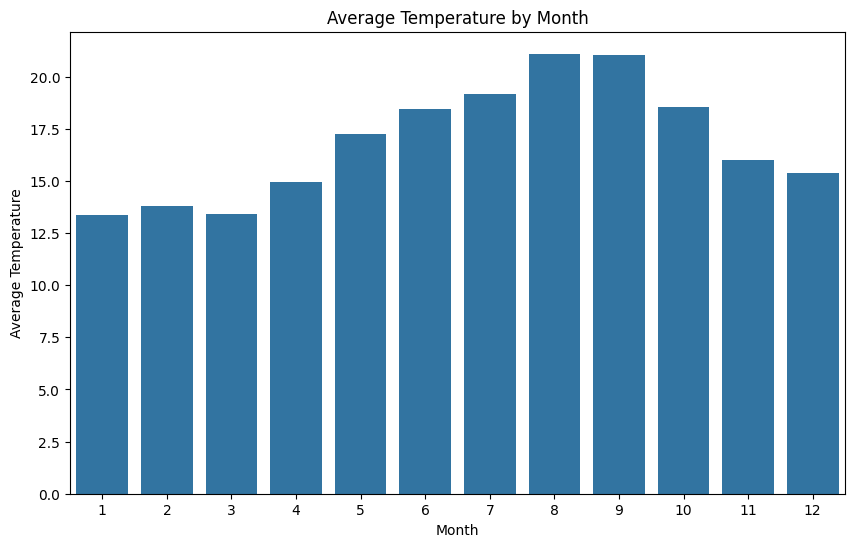

In [36]:
df_hourly['Month'] = df_hourly['DATE'].dt.month
monthly_temp = df_hourly.groupby('Month')['HourlyDryBulbTemperature'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=monthly_temp,
    x='Month',
    y='HourlyDryBulbTemperature'
)

plt.title('Average Temperature by Month')
plt.ylabel('Average Temperature')
plt.xlabel('Month')

plt.show()

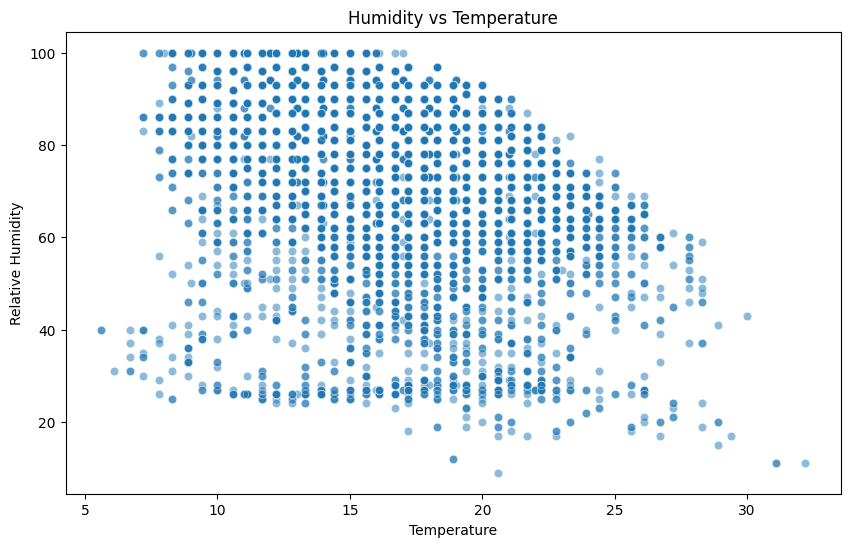

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_hourly,
    x='HourlyDryBulbTemperature',
    y='HourlyRelativeHumidity',
    alpha=0.5
)

plt.title('Humidity vs Temperature')
plt.xlabel("Temperature")
plt.ylabel('Relative Humidity')

plt.show()

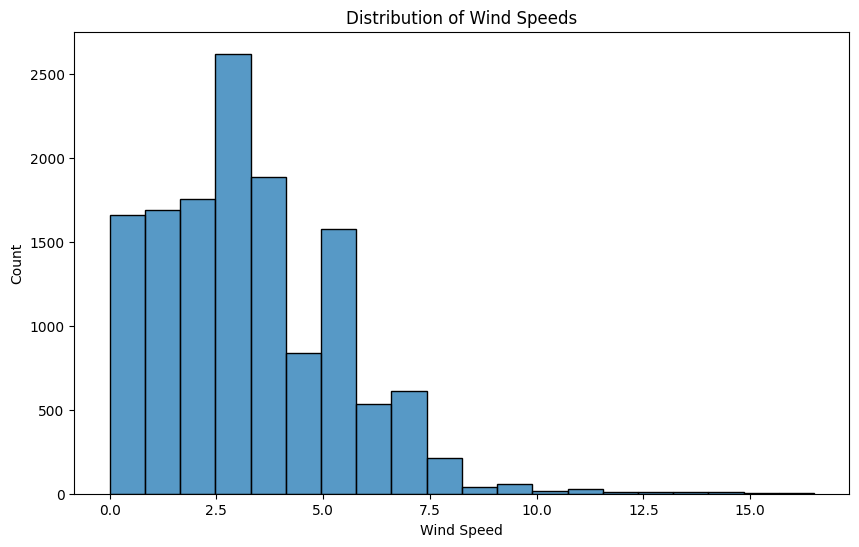

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_hourly,
    x='HourlyWindSpeed',
    bins=20,
)

plt.title('Distribution of Wind Speeds')
plt.xlabel('Wind Speed')
plt.ylabel('Count')

plt.show()

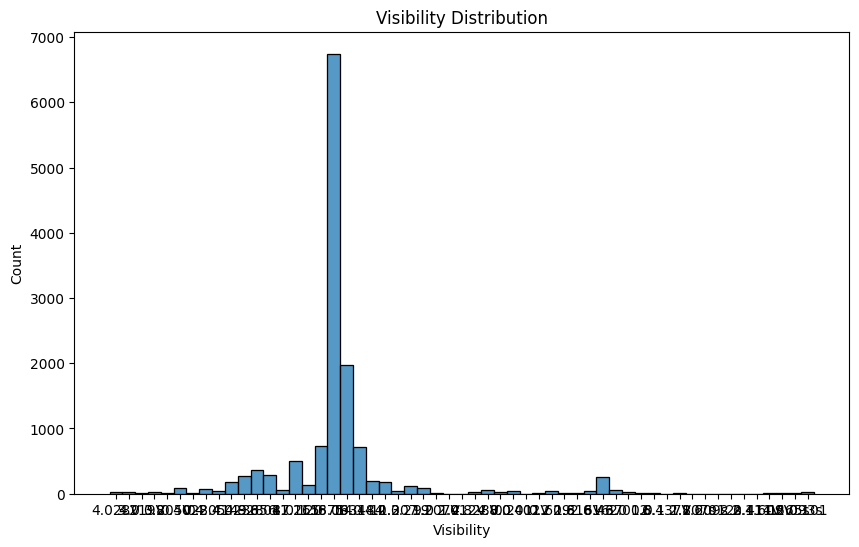

In [ ]:
# cut

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_hourly,
    x='HourlyVisibility',
    bins=20
)

plt.title('Visibility Distribution')
plt.xlabel('Visibility')
plt.ylabel('Count')

plt.show()

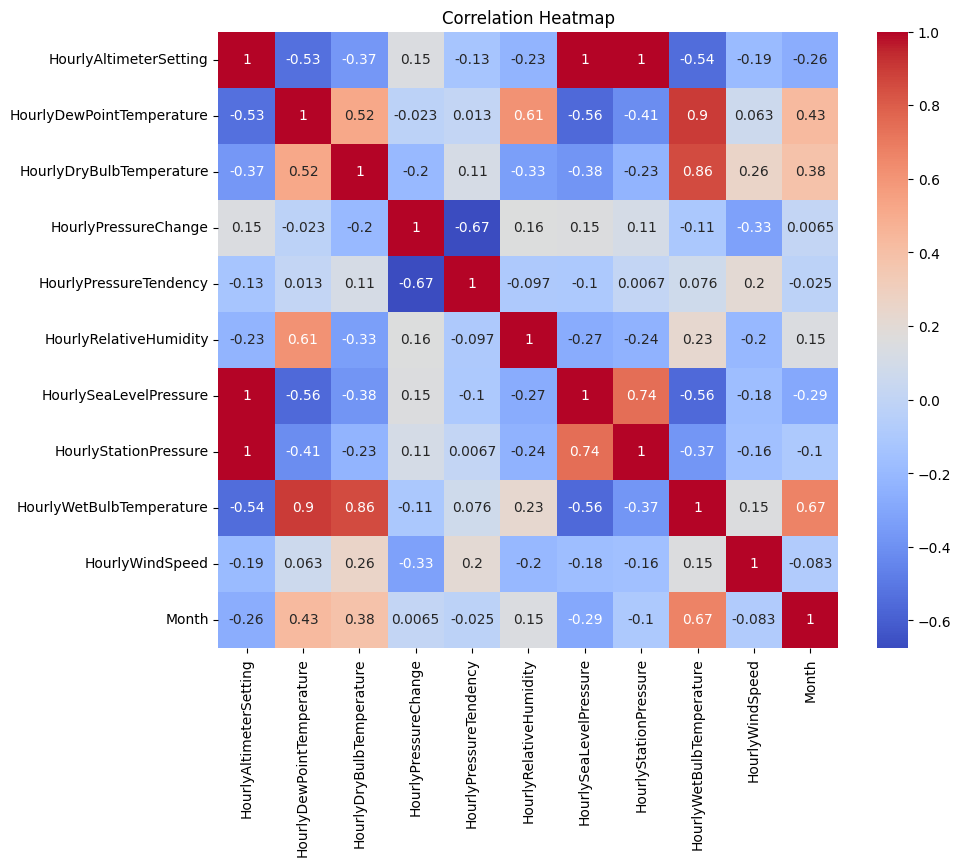

In [40]:
corr_cols = df_hourly.select_dtypes(include=['number']).columns.tolist()

corr_matrix = df_hourly[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [41]:
df_daily

,DATE,REPORT_TYPE,Sunrise,Sunset,DailyAverageDryBulbTemperature,DailyAverageWindSpeed,DailyCoolingDegreeDays,DailyDepartureFromNormalAverageTemperature,DailyHeatingDegreeDays,DailyMaximumDryBulbTemperature,DailyMinimumDryBulbTemperature,DailyPeakWindDirection,DailyPeakWindSpeed,DailyPrecipitation,DailySustainedWindDirection,DailySustainedWindSpeed,DailyWeather
0,2025-01-01T00:00:00,SOD,659.0,1655.0,11.7,1.8,0.0,-2.47,6.6,15.0,8.3,220.0,8.1,0.0,240.0,5.8,BR FG HZ
42,2025-01-02T00:00:00,SOD,659.0,1656.0,15.0,2.0,0.0,0.83,3.3,21.7,8.3,300.0,7.6,0.0,260.0,5.4,BR FG
81,2025-01-03T00:00:00,SOD,659.0,1656.0,12.8,2.3,0.0,-1.42,5.5,16.1,9.4,260.0,8.9,0.0,270.0,7.6,BR FG HZ
139,2025-01-04T00:00:00,SOD,659.0,1657.0,12.8,2.2,0.0,-1.42,5.5,16.7,8.9,240.0,7.2,0.0,250.0,5.4,BR HZ
174,2025-01-05T00:00:00,SOD,659.0,1658.0,15.6,1.8,0.0,1.32,2.7,23.9,7.2,280.0,8.9,0.0,260.0,6.7,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13793,2025-12-27T00:00:00,SOD,657.0,1651.0,12.5,2.1,0.0,-1.56,5.8,16.1,8.9,290.0,7.2,0.0,260.0,5.4,NaN
13826,2025-12-28T00:00:00,SOD,657.0,1652.0,13.3,2.0,0.0,-0.76,5.0,19.4,7.2,240.0,8.9,0.0,220.0,5.8,NaN
13859,2025-12-29T00:00:00,SOD,658.0,1653.0,15.9,1.4,0.0,1.79,2.4,23.9,7.8,110.0,8.0,0.0,110.0,5.4,NaN
13890,2025-12-30T00:00:00,SOD,658.0,1653.0,18.9,3.6,0.6,4.79,0.0,22.8,15.0,30.0,10.7,T,360.0,6.3,RA


In [43]:
df_daily['DATE'] = pd.to_datetime(df_daily['DATE'])
df_daily['Month'] = df_daily['DATE'].dt.month

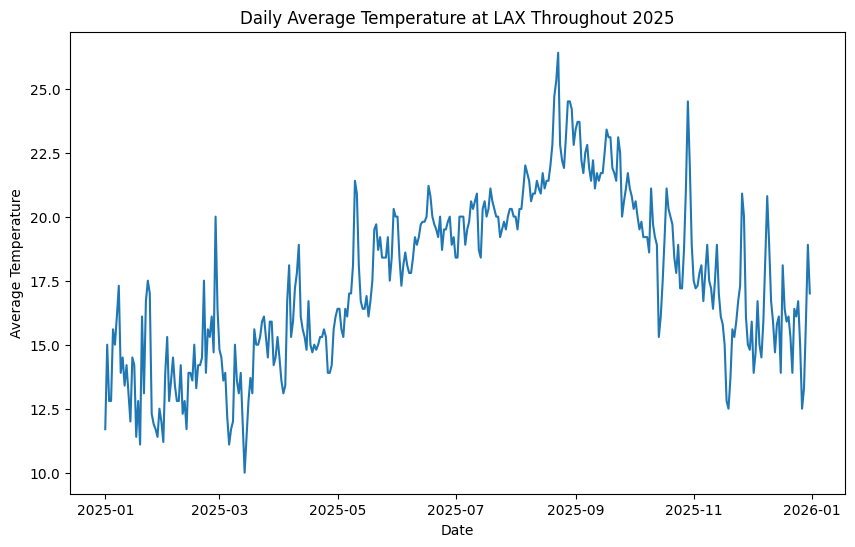

In [45]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_daily,
    x='DATE',
    y='DailyAverageDryBulbTemperature'
)

plt.title("Daily Average Temperature at LAX Throughout 2025")
plt.xlabel('Date')
plt.ylabel('Average Temperature')

plt.show()

In [42]:
df_monthly

,DATE,REPORT_TYPE,MonthlyDaysWithGT001Precip,MonthlyDaysWithGT010Precip,MonthlyDaysWithGT90Temp,MonthlyDepartureFromNormalAverageTemperature,MonthlyDepartureFromNormalCoolingDegreeDays,MonthlyDepartureFromNormalHeatingDegreeDays,MonthlyDepartureFromNormalMaximumTemperature,MonthlyDepartureFromNormalMinimumTemperature,...,MonthlyMeanTemperature,MonthlyMinimumTemperature,MonthlyTotalLiquidPrecipitation,MonthlyAverageWindSpeed,CoolingDegreeDaysSeasonToDate,MonthlyCoolingDegreeDays,HeatingDegreeDaysSeasonToDate,MonthlyHeatingDegreeDays,NormalsCoolingDegreeDay,NormalsHeatingDegreeDay
1106,2025-01-31T23:59:00,SOM,2.0,2.0,0.0,-0.71,-3.22,18.07,0.05,-1.43,...,13.68,8.24,23.9,2.6,0.0,0.0,359.2,144.4,5.8,227.4
2317,2025-02-28T23:59:00,SOM,7.0,4.0,0.0,-0.04,-2.24,-1.87,-0.05,0.02,...,14.35,10.08,67.6,3.1,1.7,1.7,472.5,113.3,7.1,207.3
3518,2025-03-31T23:59:00,SOM,9.0,4.0,0.0,-1.18,-4.72,32.66,-1.58,-0.83,...,13.88,10.39,32.8,4.1,1.7,0.0,610.6,138.1,8.5,189.8
4609,2025-04-30T23:59:00,SOM,1.0,1.0,0.0,-0.77,-8.94,14.89,-1.17,-0.42,...,15.40,11.91,4.3,3.8,2.2,0.5,699.1,88.5,17.0,132.5
5799,2025-05-31T23:59:00,SOM,1.0,0.0,0.0,0.25,0.09,-8.71,0.00,0.57,...,17.81,14.79,0.3,3.6,15.9,13.7,729.0,29.9,24.5,69.5
6945,2025-06-30T23:59:00,SOM,1.0,0.0,0.0,0.10,-2.39,-4.52,-0.11,0.25,...,19.21,16.31,0.3,3.7,44.9,29.0,731.7,2.7,56.5,13.0
8126,2025-07-31T23:59:00,SOM,0.0,0.0,0.0,-1.04,-32.17,-0.83,-1.21,-0.81,...,19.85,16.97,T,3.7,91.9,47.0,0.0,0.0,142.5,1.5
9192,2025-08-31T23:59:00,SOM,0.0,0.0,0.0,0.57,16.14,-0.56,0.56,0.53,...,22.07,18.75,0.0,NaN,207.6,115.7,0.0,0.0,179.2,1.0
10264,2025-09-30T23:59:00,SOM,1.0,0.0,0.0,0.84,23.97,-1.33,0.18,1.51,...,22.01,19.12,1.0,3.5,317.9,110.3,0.0,0.0,155.4,2.4
11432,2025-10-31T23:59:00,SOM,3.0,1.0,1.0,-0.19,-11.41,-5.54,-0.23,-0.15,...,19.31,15.29,20.4,3.1,357.1,39.2,8.9,8.9,91.1,26.0


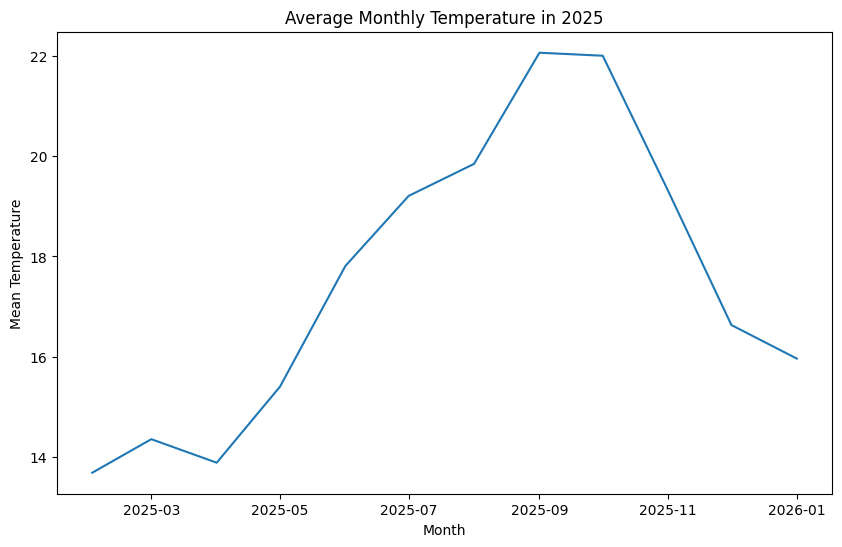

In [48]:
df_monthly['DATE'] = pd.to_datetime(df_monthly['DATE'])

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_monthly,
    x='DATE',
    y='MonthlyMeanTemperature'
)

plt.title('Average Monthly Temperature in 2025')
plt.xlabel('Month')
plt.ylabel('Mean Temperature')

plt.show()